# K Means Clustering

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs ## for creating clustered looking data
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(
    n_samples=1000,
    centers=3, ## henerally meaning 3 clusters
    n_features=2, ## This is better for visualization
    random_state=10
)
    

In [3]:
X

array([[ 4.56889035, -9.9492391 ],
       [ 2.35388502,  3.51466401],
       [-0.01750156, -6.05038477],
       ...,
       [ 4.89123569,  4.86995972],
       [ 1.09272697,  4.04641343],
       [ 0.97077866, -4.8289551 ]])

In [5]:
y[:5]

array([0, 1, 2, 2, 1])

The clustering will be done based on the X data. We are just going to use the y data to direct us

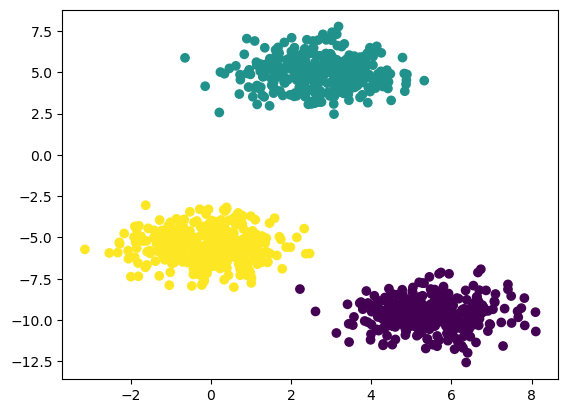

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

We can see clearly that it will form 3 clusters but we will apply ELBOW METHOD to know the k value because we will have more complicated situations compared to this.

In [7]:
## Statndardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [11]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test) ## remember to prevent data_leakage

In [12]:
from sklearn.cluster import KMeans

In [14]:
## Elbow method to select k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++') ## refer to note for why we use kmeans++
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
    
wcss

[1339.999999999999,
 571.3457849074312,
 119.48468984536365,
 97.36022198937229,
 75.71221100309434,
 53.8972723028014,
 62.534454270449515,
 44.36072530270728,
 35.36249921949501,
 33.00738529429936]

You can see that the wcss values decreases as the kvalue increased. We can plot this aganst the kvalues to get the Elbow curve

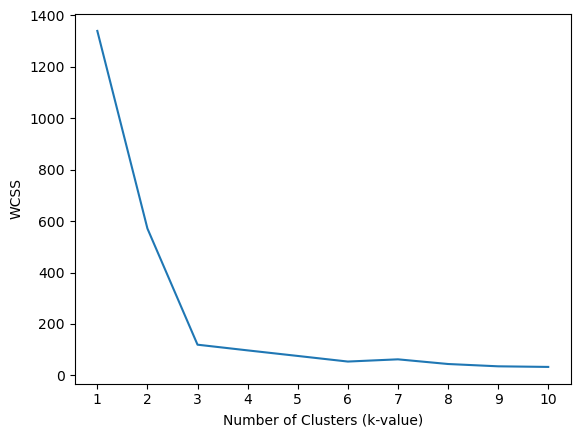

In [15]:
## plot ELBOW CURVE
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters (k-value)')
plt.ylabel('WCSS')
plt.show()

You can see the elbow curve is on k=3. So it will generate 3 clusters as the best clusters. Which is very accurate based on eye test.

In [17]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [18]:
## predict the training data
kmeans.fit_predict(X_train_scaled)

array([0, 1, 0, 1, 1, 2, 2, 0, 1, 0, 2, 2, 2, 1, 2, 2, 0, 0, 0, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 0, 1, 0, 2, 0, 0, 1, 0, 1, 1, 1, 2, 2, 1, 2,
       2, 1, 1, 1, 0, 2, 2, 1, 2, 2, 0, 2, 1, 0, 1, 0, 0, 2, 1, 1, 1, 2,
       1, 1, 2, 0, 0, 2, 2, 2, 1, 1, 1, 2, 2, 1, 2, 1, 0, 0, 0, 1, 2, 0,
       2, 1, 1, 0, 1, 0, 1, 2, 2, 2, 0, 2, 1, 2, 0, 0, 1, 1, 1, 0, 2, 0,
       1, 1, 2, 2, 1, 0, 0, 2, 2, 0, 2, 1, 2, 1, 2, 0, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 2, 0, 1,
       0, 0, 0, 2, 0, 2, 2, 2, 0, 0, 0, 1, 0, 2, 1, 1, 0, 1, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 2, 1, 2, 2, 0, 1, 1, 0, 2, 2, 0, 2, 1, 1, 2, 1, 2,
       1, 0, 0, 0, 1, 0, 1, 1, 2, 2, 1, 1, 2, 0, 1, 1, 2, 1, 0, 0, 0, 0,
       0, 2, 1, 1, 1, 0, 2, 0, 2, 0, 1, 2, 0, 1, 2, 1, 0, 1, 0, 0, 2, 1,
       2, 1, 0, 0, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 2, 0, 1, 0, 0, 2, 0,
       2, 2, 1, 0, 0, 2, 1, 2, 0, 0, 1, 1, 2, 1, 1, 1, 2, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 0,

In [19]:
## Get y_pred with test data
y_pred=kmeans.predict(X_test_scaled)

In [20]:
y_pred

array([2, 1, 1, 0, 1, 2, 2, 0, 2, 2, 1, 1, 0, 2, 0, 2, 1, 2, 1, 2, 1, 1,
       2, 0, 0, 2, 2, 2, 0, 2, 0, 2, 1, 1, 2, 2, 0, 0, 1, 0, 1, 0, 2, 2,
       2, 0, 2, 0, 2, 0, 2, 1, 1, 0, 2, 1, 0, 1, 2, 1, 2, 0, 0, 2, 0, 1,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 1, 0, 0, 2, 2, 0, 1, 2, 2, 0, 0, 2,
       1, 2, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 1, 0, 1, 0, 0, 1, 0, 1, 2, 2, 1,
       1, 2, 2, 2, 1, 0, 0, 2, 1, 2, 0, 0, 0, 2, 1, 1, 1, 0, 0, 0, 2, 0,
       1, 1, 0, 0, 2, 2, 1, 1, 2, 2, 0, 2, 1, 0, 1, 1, 2, 1, 2, 2, 1, 2,
       0, 0, 1, 1, 2, 2, 1, 1, 2, 1, 2, 0, 0, 1, 2, 2, 0, 2, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 2, 2, 0, 1, 2, 1, 1, 0, 2, 0, 1, 2, 2, 0, 1, 1,
       1, 0, 0, 1, 0, 2, 0, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 1, 1, 2, 2, 1,
       1, 0, 2, 2, 2, 1, 0, 1, 0, 1, 1, 2, 2, 1, 2, 0, 1, 2, 1, 0, 1, 2,
       1, 2, 1, 1, 2, 0, 0, 2, 1, 2, 2, 2, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0,
       2, 0, 0, 0, 2, 0, 2, 2, 1, 2, 1, 0, 2, 0, 0,

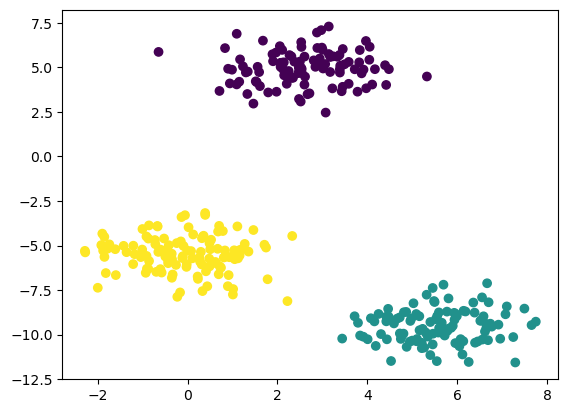

In [21]:
## plot test data to view the cluster
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

Later we can check the accuracy and classification report.

Sometimes the k value might not be easily identified from the Elbow curve because of some unstability it can get complex. Then we have to **VALIDATE** the kvalue. There are two ways to do this:

1. Knee Locator
2. Slhouette Scoring

In [ ]:
## Validating the k value